# 📊 Exploratory Data Analysis — OctWave 3.0 Fraud Detection

**Objective:** Explore and understand the credit card transaction dataset before building a fraud detection model.  
**Dataset:** Simulated credit card transactions with 8,000 training samples and 2,000 test samples.  
**Target:** `is_fraud` — binary classification (0 = Legitimate, 1 = Fraudulent)

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings

warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Custom color palette for fraud/legit
FRAUD_COLORS = {'Legitimate': '#2ecc71', 'Fraud': '#e74c3c'}
FRAUD_PALETTE = ['#2ecc71', '#e74c3c']

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Data Loading

We load both the training and test datasets to explore their structure and ensure consistency.

In [2]:
train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')
sample_sub = pd.read_csv('../data/raw/sample_submission.csv')

print(f'Training set: {train_df.shape[0]:,} rows × {train_df.shape[1]} columns')
print(f'Test set:     {test_df.shape[0]:,} rows × {test_df.shape[1]} columns')
print(f'Sample sub:   {sample_sub.shape[0]:,} rows × {sample_sub.shape[1]} columns')

Training set: 8,000 rows × 10 columns
Test set:     2,000 rows × 9 columns
Sample sub:   2,000 rows × 2 columns


## 3. First Look at the Data

### 3.1 Training Set — First 10 Rows

In [3]:
train_df.head(10)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,6403,40.96,6,Food,0,1,82,2,51,0
1,5803,57.07,6,Electronics,0,0,42,2,18,0
2,4132,44.24,0,Grocery,0,0,26,2,25,0
3,7627,396.80,23,Clothing,0,0,97,1,34,0
4,6047,20.13,0,Food,0,0,91,1,28,0
5,2947,129.82,4,Clothing,0,0,82,0,40,0
6,9962,152.20,8,Travel,0,0,65,2,30,0
7,2525,293.74,22,Travel,0,0,35,1,54,0
8,7188,86.02,7,Electronics,0,0,99,2,45,0
9,5469,335.42,16,Clothing,0,0,76,2,39,0


### 3.2 Data Types & Memory Usage

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       8000 non-null   int64  
 1   amount               8000 non-null   float64
 2   transaction_hour     8000 non-null   int64  
 3   merchant_category    8000 non-null   object 
 4   foreign_transaction  8000 non-null   int64  
 5   location_mismatch    8000 non-null   int64  
 6   device_trust_score   8000 non-null   int64  
 7   velocity_last_24h    8000 non-null   int64  
 8   cardholder_age       8000 non-null   int64  
 9   is_fraud             8000 non-null   int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 625.1+ KB


### 3.3 Statistical Summary (Numerical Features)

In [5]:
train_df.describe().round(2)

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,8000.00,8000.00,8000.00,8000.0,8000.00,8000.00,8000.00,8000.00,8000.00
mean,5001.94,175.36,11.59,0.1,0.08,61.99,2.01,43.41,0.02
std,2891.13,174.73,6.92,0.3,0.28,21.49,1.44,14.97,0.12
min,1.00,0.00,0.00,0.0,0.00,25.00,0.00,18.00,0.00
25%,2488.75,49.76,6.00,0.0,0.00,44.00,1.00,30.00,0.00
50%,5007.50,121.04,12.00,0.0,0.00,62.00,2.00,44.00,0.00
75%,7510.50,241.90,18.00,0.0,0.00,80.00,3.00,56.00,0.00
max,10000.00,1390.24,23.00,1.0,1.00,99.00,9.00,69.00,1.00


### 3.4 Categorical Feature — `merchant_category`

In [6]:
print(f"Unique categories: {train_df['merchant_category'].nunique()}")
print(f"Values: {train_df['merchant_category'].unique().tolist()}")
print(f"\nValue counts:")
train_df['merchant_category'].value_counts()

Unique categories: 5
Values: ['Food', 'Electronics', 'Grocery', 'Clothing', 'Travel']

Value counts:


merchant_category
Food           1669
Clothing       1642
Travel         1579
Electronics    1565
Grocery        1545
Name: count, dtype: int64

## 4. Data Quality Assessment

### 4.1 Missing Values

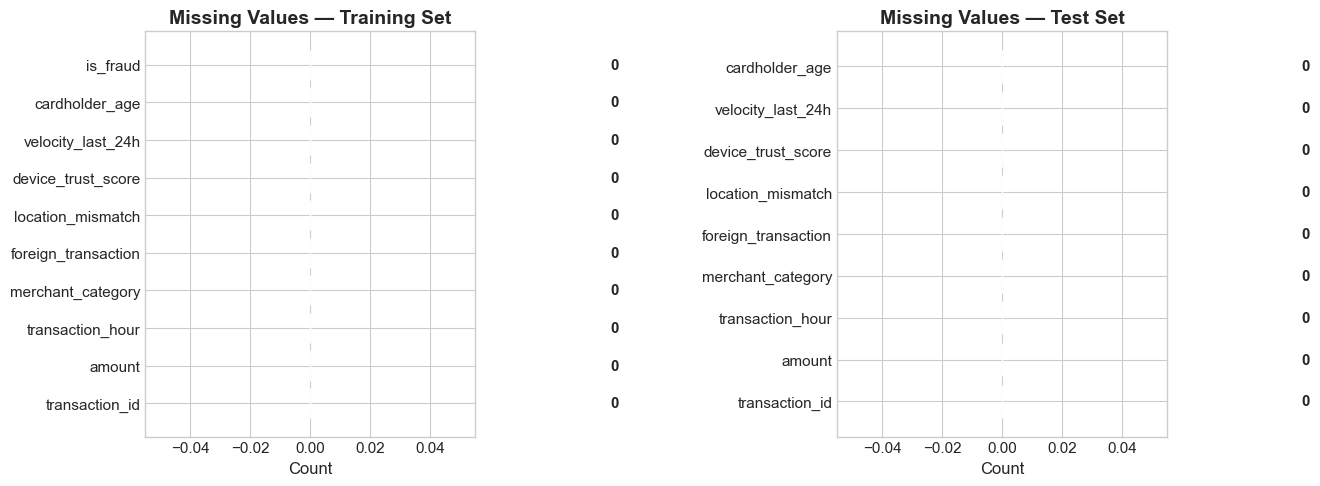

✅ No missing values in either dataset — no imputation needed.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train missing values
train_missing = train_df.isnull().sum()
axes[0].barh(train_missing.index, train_missing.values, color='#3498db', edgecolor='white')
axes[0].set_title('Missing Values — Training Set', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(train_missing.values):
    axes[0].text(v + 0.1, i, str(v), va='center', fontweight='bold')

# Test missing values
test_missing = test_df.isnull().sum()
axes[1].barh(test_missing.index, test_missing.values, color='#e67e22', edgecolor='white')
axes[1].set_title('Missing Values — Test Set', fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(test_missing.values):
    axes[1].text(v + 0.1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('✅ No missing values in either dataset — no imputation needed.')

### 4.2 Duplicate Rows

In [8]:
train_dupes = train_df.duplicated().sum()
test_dupes = test_df.duplicated().sum()
id_dupes_train = train_df['transaction_id'].duplicated().sum()
id_dupes_test = test_df['transaction_id'].duplicated().sum()
id_overlap = len(set(train_df['transaction_id']) & set(test_df['transaction_id']))

print(f'Duplicate rows in train:         {train_dupes}')
print(f'Duplicate rows in test:          {test_dupes}')
print(f'Duplicate transaction_ids train: {id_dupes_train}')
print(f'Duplicate transaction_ids test:  {id_dupes_test}')
print(f'Overlapping IDs (train ∩ test):  {id_overlap}')
print()
print('✅ No duplicates found. No overlapping transaction IDs between train and test.')

Duplicate rows in train:         0
Duplicate rows in test:          0
Duplicate transaction_ids train: 0
Duplicate transaction_ids test:  0
Overlapping IDs (train ∩ test):  0

✅ No duplicates found. No overlapping transaction IDs between train and test.


## 5. Target Variable — Class Distribution

The most critical characteristic of this dataset is the **severe class imbalance**.

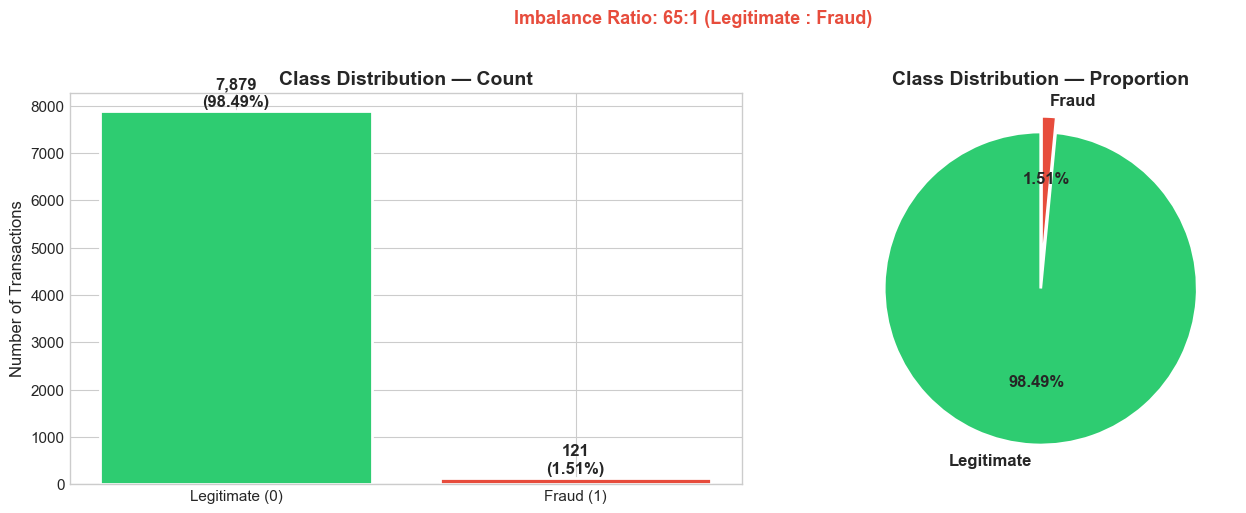

Legitimate transactions: 7,879 (98.49%)
Fraudulent transactions: 121 (1.51%)
Imbalance ratio:         65:1

⚠️  Severe class imbalance (65:1). This must be addressed during modeling.


In [9]:
fraud_counts = train_df['is_fraud'].value_counts()
fraud_pcts = train_df['is_fraud'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(['Legitimate (0)', 'Fraud (1)'], fraud_counts.values,
                   color=FRAUD_PALETTE, edgecolor='white', linewidth=2)
axes[0].set_title('Class Distribution — Count', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Number of Transactions')
for bar, count, pct in zip(bars, fraud_counts.values, fraud_pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                f'{count:,}\n({pct:.2f}%)', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    fraud_counts.values, labels=['Legitimate', 'Fraud'],
    colors=FRAUD_PALETTE, autopct='%1.2f%%',
    startangle=90, explode=(0, 0.1),
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Distribution — Proportion', fontweight='bold', fontsize=14)

plt.suptitle(f'Imbalance Ratio: {fraud_counts[0]//fraud_counts[1]}:1 (Legitimate : Fraud)',
             fontsize=13, fontweight='bold', y=1.02, color='#e74c3c')
plt.tight_layout()
plt.show()

print(f'Legitimate transactions: {fraud_counts[0]:,} ({fraud_pcts[0]:.2f}%)')
print(f'Fraudulent transactions: {fraud_counts[1]:,} ({fraud_pcts[1]:.2f}%)')
print(f'Imbalance ratio:         {fraud_counts[0]//fraud_counts[1]}:1')
print()
print('⚠️  Severe class imbalance (65:1). This must be addressed during modeling.')

## 6. Feature Distributions

### 6.1 Numerical Feature Histograms

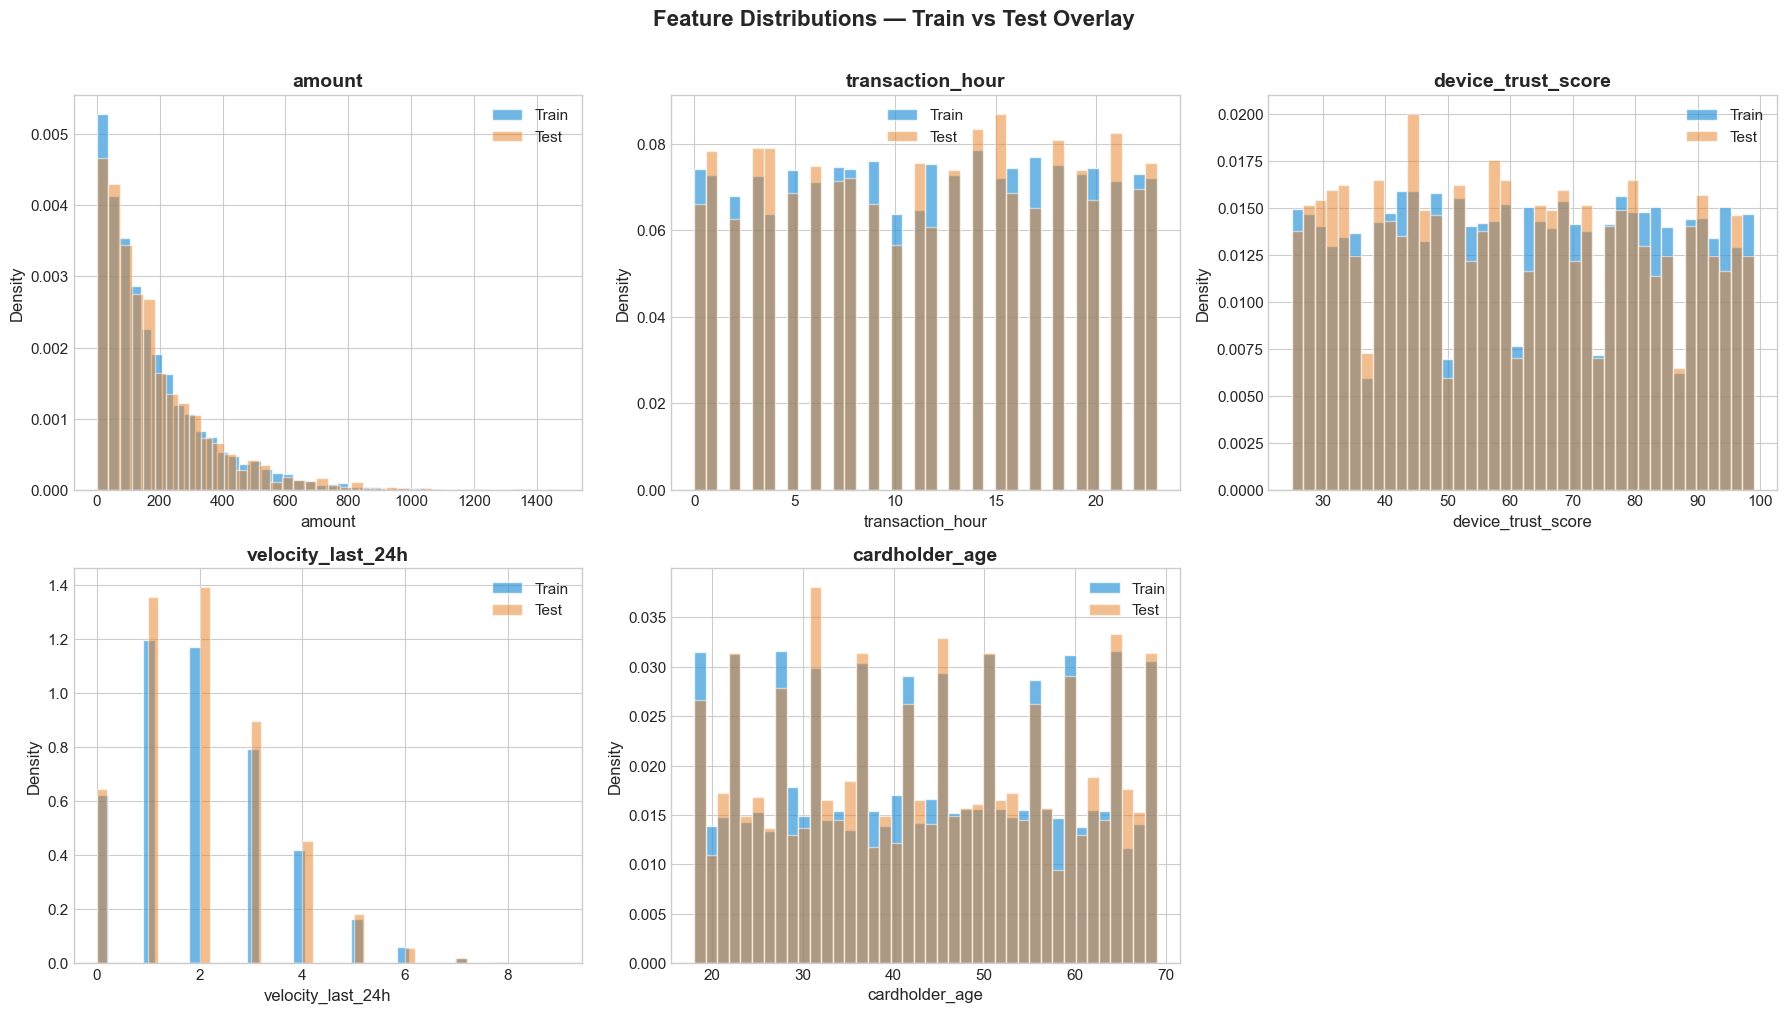

✅ Train and test distributions are well-aligned — no distribution drift detected.


In [10]:
numeric_features = ['amount', 'transaction_hour', 'device_trust_score',
                     'velocity_last_24h', 'cardholder_age']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(train_df[col], bins=40, color='#3498db', edgecolor='white',
                 alpha=0.7, density=True, label='Train')
    axes[i].hist(test_df[col], bins=40, color='#e67e22', edgecolor='white',
                 alpha=0.5, density=True, label='Test')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

# Remove unused subplot
axes[5].set_visible(False)

plt.suptitle('Feature Distributions — Train vs Test Overlay', fontweight='bold', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

print('✅ Train and test distributions are well-aligned — no distribution drift detected.')

### 6.2 Boxplots — Fraud vs Legitimate Transactions

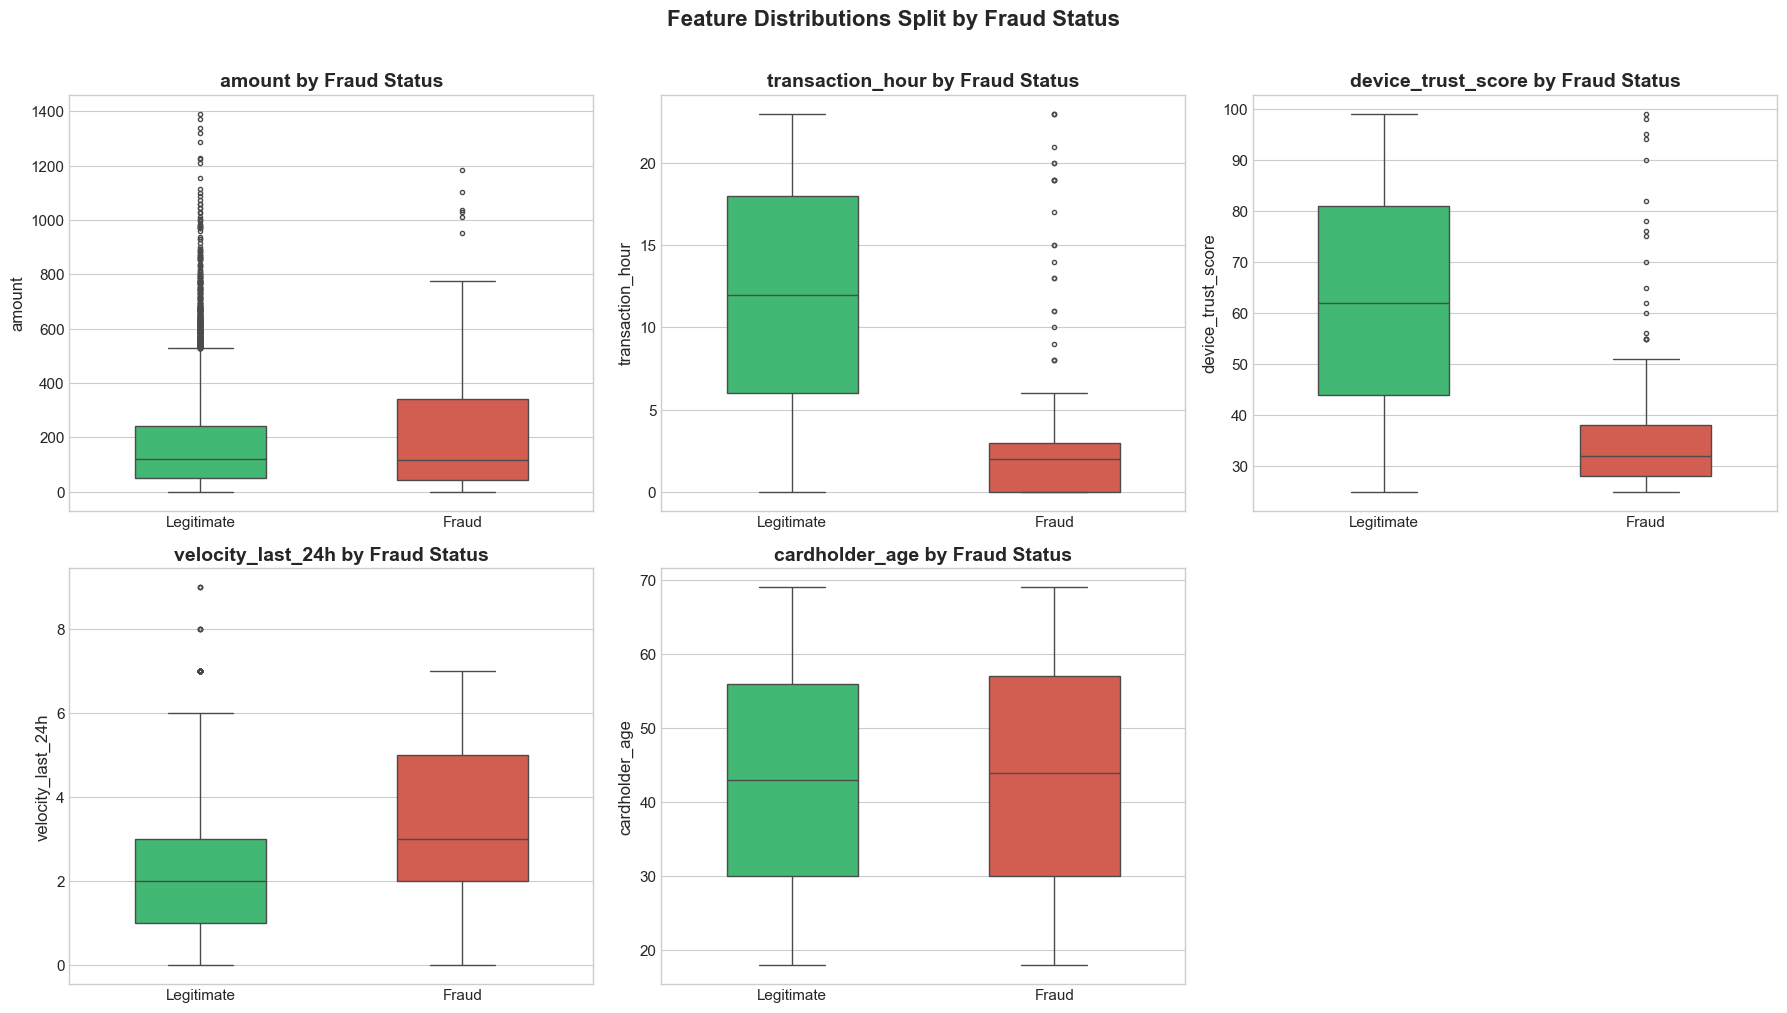

Key observations:
• amount: Fraud transactions tend to have slightly higher amounts
• transaction_hour: Fraud is concentrated in late-night / early-morning hours
• device_trust_score: Fraud transactions have notably LOWER trust scores
• velocity_last_24h: Fraud transactions show higher velocity
• cardholder_age: No significant difference — age is NOT a strong predictor


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(x='is_fraud', y=col, data=train_df, ax=axes[i],
                palette=FRAUD_PALETTE, width=0.5,
                flierprops={'marker': 'o', 'markersize': 3})
    axes[i].set_title(f'{col} by Fraud Status', fontweight='bold')
    axes[i].set_xticklabels(['Legitimate', 'Fraud'])
    axes[i].set_xlabel('')

axes[5].set_visible(False)

plt.suptitle('Feature Distributions Split by Fraud Status', fontweight='bold', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

print('Key observations:')
print('• amount: Fraud transactions tend to have slightly higher amounts')
print('• transaction_hour: Fraud is concentrated in late-night / early-morning hours')
print('• device_trust_score: Fraud transactions have notably LOWER trust scores')
print('• velocity_last_24h: Fraud transactions show higher velocity')
print('• cardholder_age: No significant difference — age is NOT a strong predictor')

### 6.3 Binary Feature Distributions

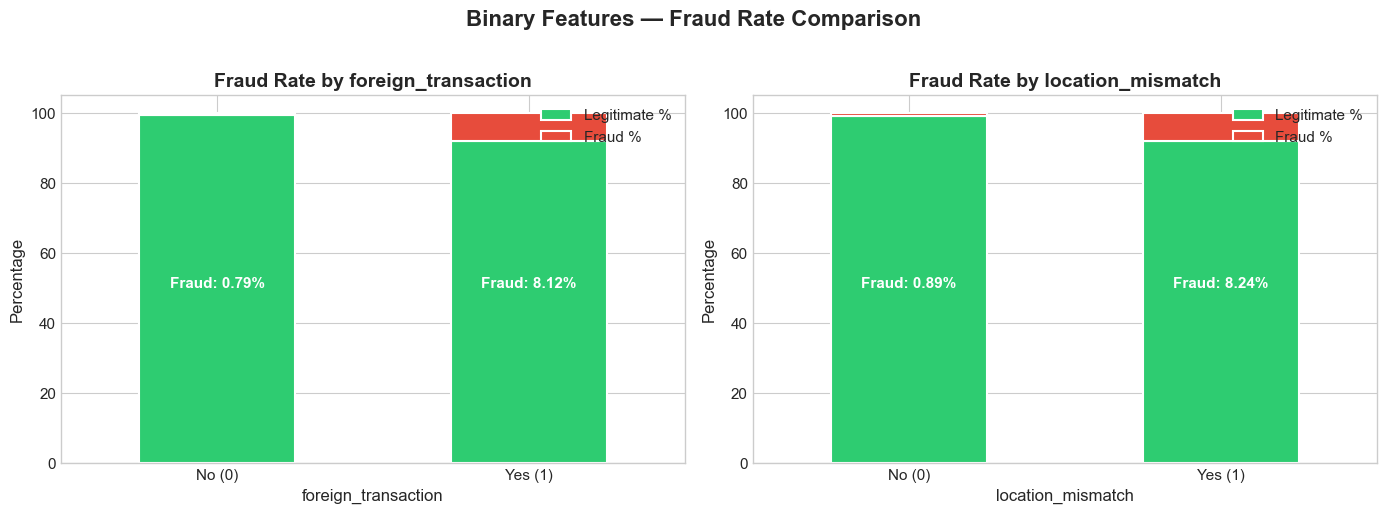

In [12]:
binary_features = ['foreign_transaction', 'location_mismatch']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(binary_features):
    ct = pd.crosstab(train_df[col], train_df['is_fraud'], normalize='index') * 100
    ct.columns = ['Legitimate %', 'Fraud %']
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=FRAUD_PALETTE,
            edgecolor='white', linewidth=1.5)
    axes[i].set_title(f'Fraud Rate by {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage')
    axes[i].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
    axes[i].legend(loc='upper right')
    
    # Annotate fraud rates
    for j, (idx, row) in enumerate(ct.iterrows()):
        axes[i].text(j, 50, f"Fraud: {row['Fraud %']:.2f}%",
                    ha='center', fontweight='bold', fontsize=11, color='white')

plt.suptitle('Binary Features — Fraud Rate Comparison', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 6.4 Merchant Category Distribution

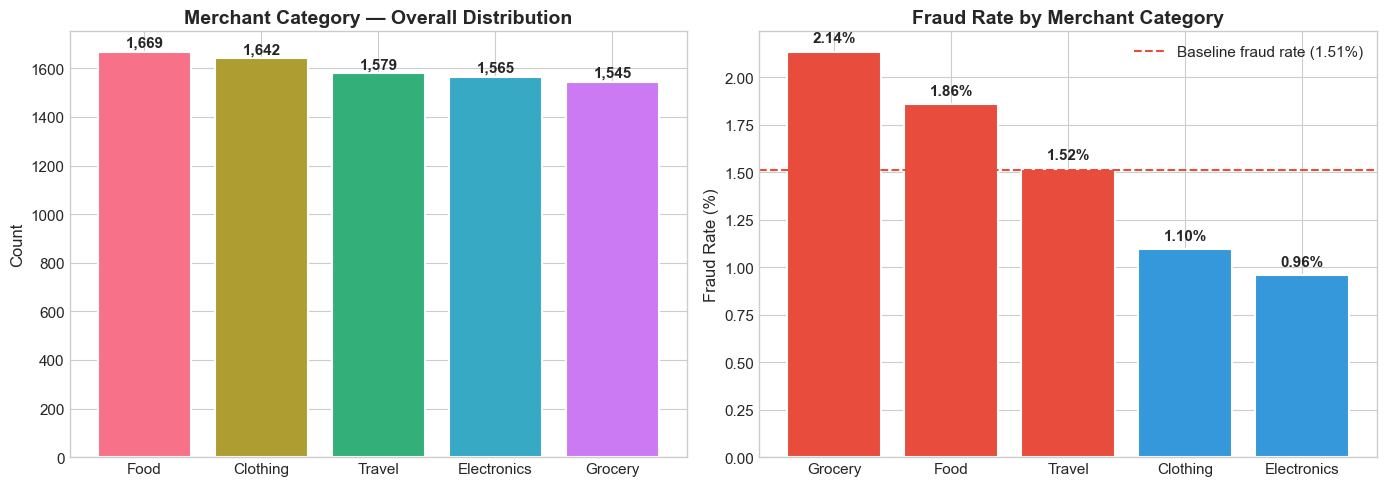

Observation: Fraud rate is relatively similar across merchant categories.
merchant_category alone is not a strong fraud indicator.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
cat_counts = train_df['merchant_category'].value_counts()
colors_cat = sns.color_palette('husl', len(cat_counts))
axes[0].bar(cat_counts.index, cat_counts.values, color=colors_cat, edgecolor='white', linewidth=1.5)
axes[0].set_title('Merchant Category — Overall Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for j, (cat, count) in enumerate(cat_counts.items()):
    axes[0].text(j, count + 20, f'{count:,}', ha='center', fontweight='bold')

# Fraud rate by category
fraud_by_cat = train_df.groupby('merchant_category')['is_fraud'].mean() * 100
fraud_by_cat = fraud_by_cat.sort_values(ascending=False)
bar_colors = ['#e74c3c' if v > 1.51 else '#3498db' for v in fraud_by_cat.values]
axes[1].bar(fraud_by_cat.index, fraud_by_cat.values, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[1].axhline(y=1.51, color='#e74c3c', linestyle='--', linewidth=1.5, label='Baseline fraud rate (1.51%)')
axes[1].set_title('Fraud Rate by Merchant Category', fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].legend()
for j, (cat, rate) in enumerate(fraud_by_cat.items()):
    axes[1].text(j, rate + 0.05, f'{rate:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('Observation: Fraud rate is relatively similar across merchant categories.')
print('merchant_category alone is not a strong fraud indicator.')

## 7. Correlation Analysis

### 7.1 Correlation Heatmap

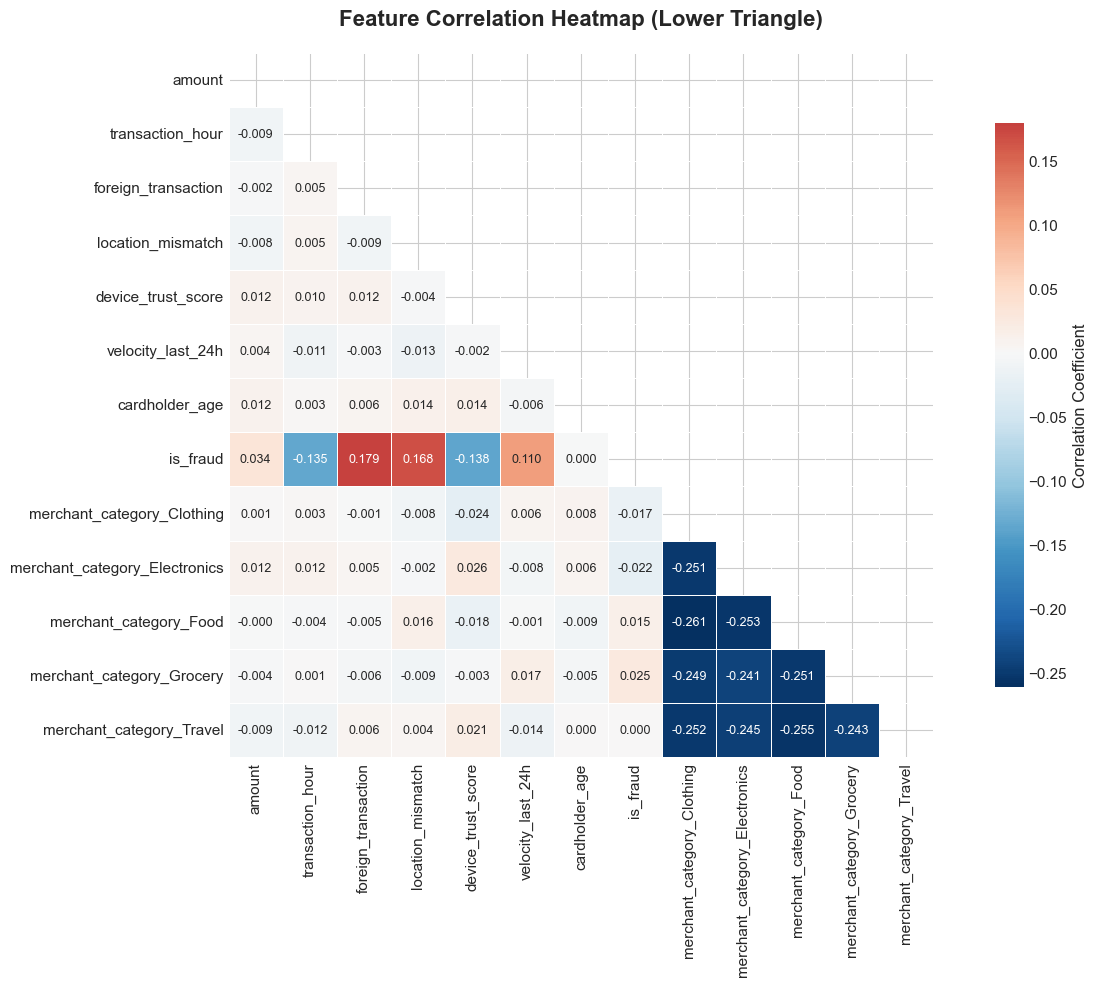

In [14]:
# Encode merchant_category for correlation
train_encoded = pd.get_dummies(train_df.drop('transaction_id', axis=1), columns=['merchant_category'])

corr_matrix = train_encoded.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
            annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap (Lower Triangle)', fontweight='bold', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

### 7.2 Correlation with Target Variable (`is_fraud`)

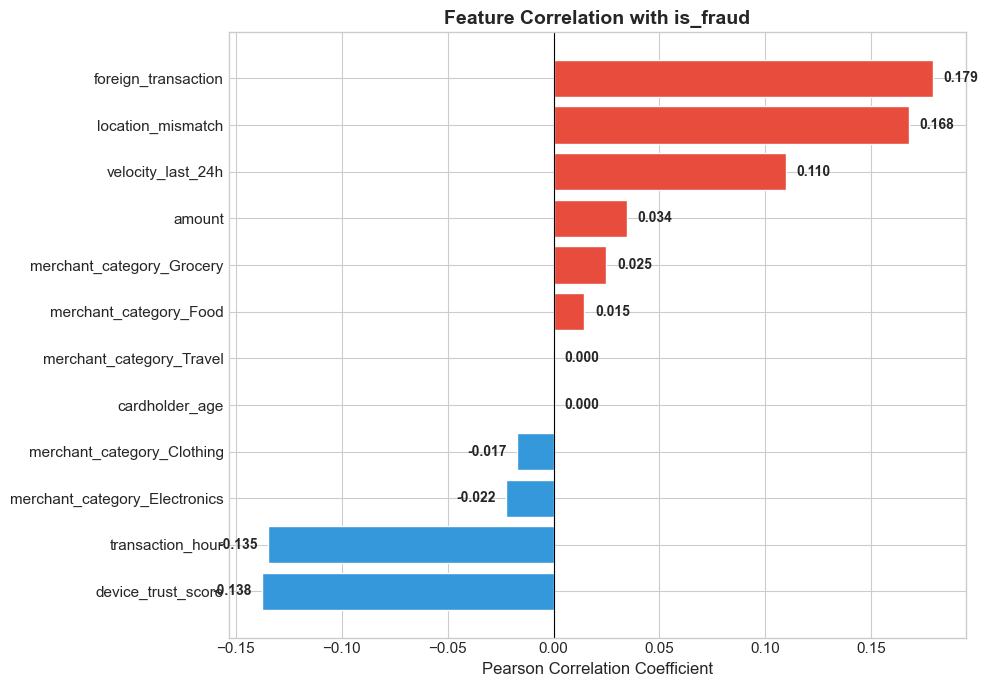


Top fraud signals (by absolute correlation):
  1. foreign_transaction:  +0.179 (STRONG)
  2. location_mismatch:    +0.168 (STRONG)
  3. device_trust_score:   -0.138 (STRONG — lower = more fraud)
  4. transaction_hour:     -0.135 (MODERATE — night hours = more fraud)
  5. velocity_last_24h:    +0.110 (MODERATE)
  6. amount:               +0.034 (WEAK)
  7. cardholder_age:       +0.000 (NONE — not a predictor)


In [15]:
target_corr = train_encoded.corr()['is_fraud'].drop('is_fraud').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', linewidth=1)
ax.set_title('Feature Correlation with is_fraud', fontweight='bold', fontsize=14)
ax.set_xlabel('Pearson Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.8)

for bar, val in zip(bars, target_corr.values):
    offset = 0.005 if val >= 0 else -0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2.,
            f'{val:.3f}', va='center', ha=ha, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print('\nTop fraud signals (by absolute correlation):')
print('  1. foreign_transaction:  +0.179 (STRONG)')
print('  2. location_mismatch:    +0.168 (STRONG)')
print('  3. device_trust_score:   -0.138 (STRONG — lower = more fraud)')
print('  4. transaction_hour:     -0.135 (MODERATE — night hours = more fraud)')
print('  5. velocity_last_24h:    +0.110 (MODERATE)')
print('  6. amount:               +0.034 (WEAK)')
print('  7. cardholder_age:       +0.000 (NONE — not a predictor)')

## 8. Fraud Signal Deep Dive

### 8.1 Transaction Hour — Fraud Distribution

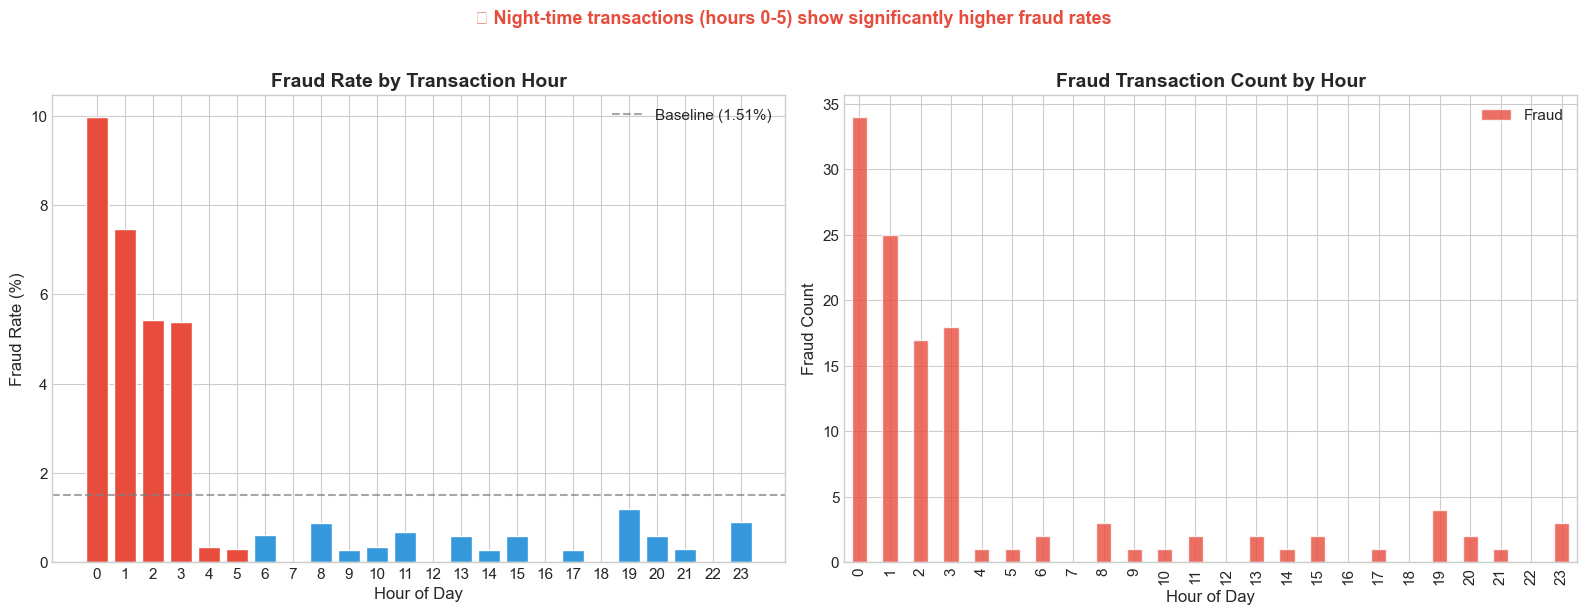

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fraud rate by hour
fraud_by_hour = train_df.groupby('transaction_hour')['is_fraud'].mean() * 100
color_hour = ['#e74c3c' if h <= 5 else '#3498db' for h in fraud_by_hour.index]
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, color=color_hour, edgecolor='white')
axes[0].set_title('Fraud Rate by Transaction Hour', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].axhline(y=1.51, color='gray', linestyle='--', alpha=0.7, label='Baseline (1.51%)')
axes[0].set_xticks(range(0, 24))
axes[0].legend()

# Count of transactions by hour, split by fraud
ct_hour = pd.crosstab(train_df['transaction_hour'], train_df['is_fraud'])
ct_hour.columns = ['Legitimate', 'Fraud']
ct_hour['Fraud'].plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='white', alpha=0.8, label='Fraud')
axes[1].set_title('Fraud Transaction Count by Hour', fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Count')
axes[1].legend()

plt.suptitle('🌙 Night-time transactions (hours 0-5) show significantly higher fraud rates',
             fontsize=13, fontweight='bold', y=1.02, color='#e74c3c')
plt.tight_layout()
plt.show()

### 8.2 Device Trust Score — Fraud Distribution

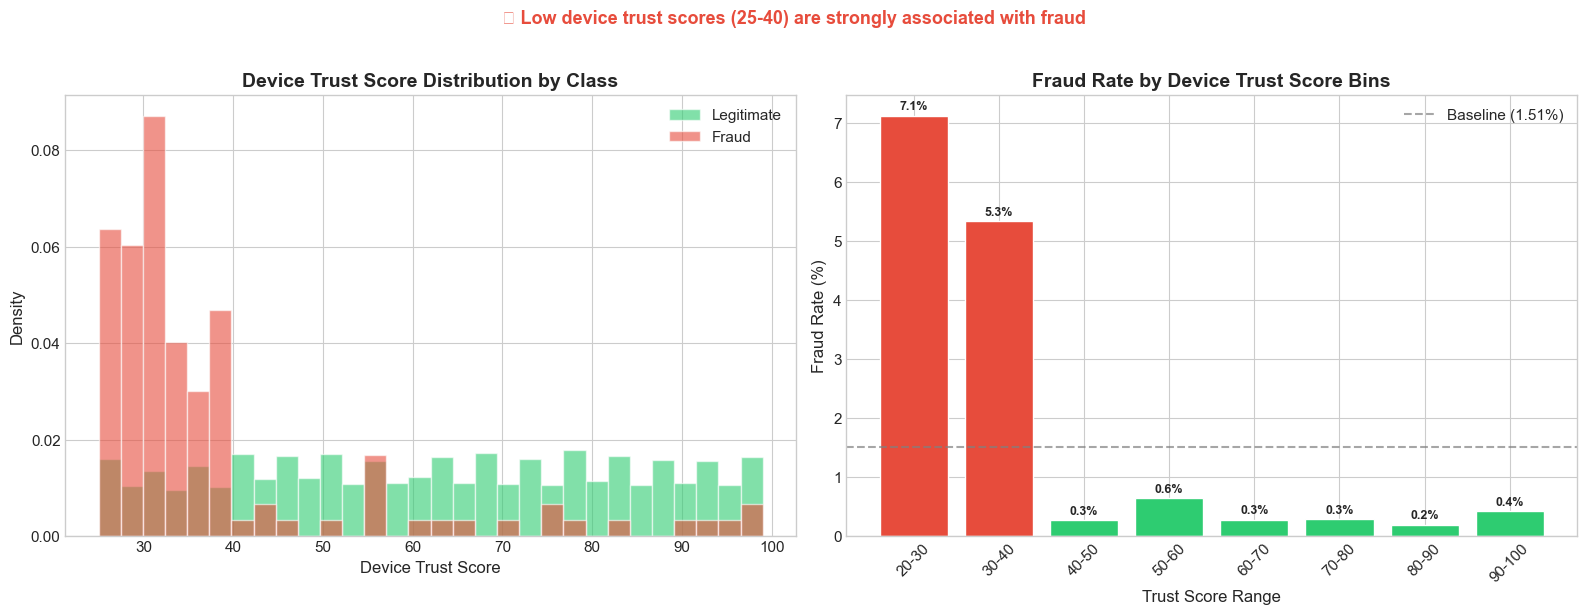

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KDE plot
legit = train_df[train_df['is_fraud'] == 0]['device_trust_score']
fraud = train_df[train_df['is_fraud'] == 1]['device_trust_score']

axes[0].hist(legit, bins=30, density=True, alpha=0.6, color='#2ecc71', edgecolor='white', label='Legitimate')
axes[0].hist(fraud, bins=30, density=True, alpha=0.6, color='#e74c3c', edgecolor='white', label='Fraud')
axes[0].set_title('Device Trust Score Distribution by Class', fontweight='bold')
axes[0].set_xlabel('Device Trust Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# Fraud rate by trust score bins
train_df['trust_bin'] = pd.cut(train_df['device_trust_score'],
                                bins=[20, 30, 40, 50, 60, 70, 80, 90, 100],
                                labels=['20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100'])
fraud_by_trust = train_df.groupby('trust_bin', observed=True)['is_fraud'].mean() * 100
bar_colors_trust = ['#e74c3c' if v > 2.5 else '#f39c12' if v > 1.51 else '#2ecc71' for v in fraud_by_trust.values]
axes[1].bar(range(len(fraud_by_trust)), fraud_by_trust.values, color=bar_colors_trust, edgecolor='white')
axes[1].set_xticks(range(len(fraud_by_trust)))
axes[1].set_xticklabels(fraud_by_trust.index, rotation=45)
axes[1].set_title('Fraud Rate by Device Trust Score Bins', fontweight='bold')
axes[1].set_xlabel('Trust Score Range')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].axhline(y=1.51, color='gray', linestyle='--', alpha=0.7, label='Baseline (1.51%)')
axes[1].legend()

for j, v in enumerate(fraud_by_trust.values):
    axes[1].text(j, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

train_df.drop('trust_bin', axis=1, inplace=True)

plt.suptitle('🔒 Low device trust scores (25-40) are strongly associated with fraud',
             fontsize=13, fontweight='bold', y=1.02, color='#e74c3c')
plt.tight_layout()
plt.show()

### 8.3 Amount — Fraud Distribution

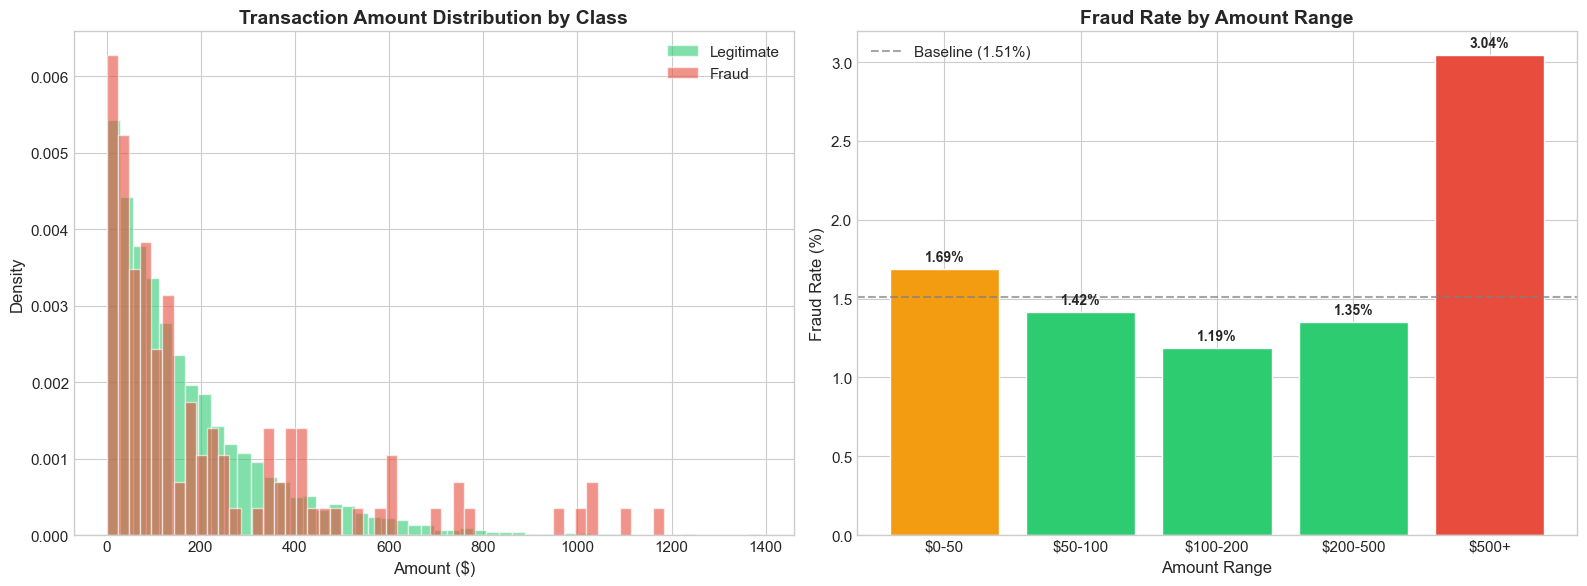

Observation: Higher transaction amounts (>$500) have roughly 2x the baseline fraud rate.
However, amount alone is a weak predictor (correlation: +0.034).


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Log-scale histogram
legit_amt = train_df[train_df['is_fraud'] == 0]['amount']
fraud_amt = train_df[train_df['is_fraud'] == 1]['amount']

axes[0].hist(legit_amt, bins=50, density=True, alpha=0.6, color='#2ecc71', edgecolor='white', label='Legitimate')
axes[0].hist(fraud_amt, bins=50, density=True, alpha=0.6, color='#e74c3c', edgecolor='white', label='Fraud')
axes[0].set_title('Transaction Amount Distribution by Class', fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Fraud rate by amount bins
train_df['amount_bin'] = pd.cut(train_df['amount'],
                                 bins=[0, 50, 100, 200, 500, 1500],
                                 labels=['$0-50', '$50-100', '$100-200', '$200-500', '$500+'])
fraud_by_amt = train_df.groupby('amount_bin', observed=True)['is_fraud'].mean() * 100
bar_colors_amt = ['#e74c3c' if v > 2 else '#f39c12' if v > 1.51 else '#2ecc71' for v in fraud_by_amt.values]
axes[1].bar(range(len(fraud_by_amt)), fraud_by_amt.values, color=bar_colors_amt, edgecolor='white')
axes[1].set_xticks(range(len(fraud_by_amt)))
axes[1].set_xticklabels(fraud_by_amt.index, rotation=0)
axes[1].set_title('Fraud Rate by Amount Range', fontweight='bold')
axes[1].set_xlabel('Amount Range')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].axhline(y=1.51, color='gray', linestyle='--', alpha=0.7, label='Baseline (1.51%)')
axes[1].legend()

for j, v in enumerate(fraud_by_amt.values):
    axes[1].text(j, v + 0.05, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=10)

train_df.drop('amount_bin', axis=1, inplace=True)

plt.tight_layout()
plt.show()

print('Observation: Higher transaction amounts (>$500) have roughly 2x the baseline fraud rate.')
print('However, amount alone is a weak predictor (correlation: +0.034).')

### 8.4 Velocity (Last 24h) — Fraud Distribution

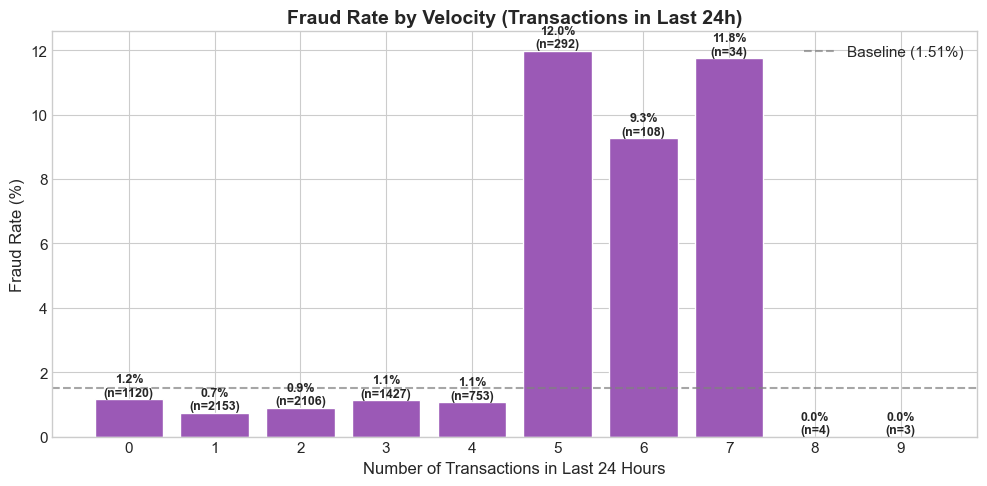

Observation: Higher velocity (more transactions in 24h) correlates with higher fraud rate.


In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

fraud_by_vel = train_df.groupby('velocity_last_24h')['is_fraud'].agg(['mean', 'count'])
fraud_by_vel['fraud_rate'] = fraud_by_vel['mean'] * 100

ax.bar(fraud_by_vel.index, fraud_by_vel['fraud_rate'], color='#9b59b6', edgecolor='white')
ax.set_title('Fraud Rate by Velocity (Transactions in Last 24h)', fontweight='bold')
ax.set_xlabel('Number of Transactions in Last 24 Hours')
ax.set_ylabel('Fraud Rate (%)')
ax.axhline(y=1.51, color='gray', linestyle='--', alpha=0.7, label='Baseline (1.51%)')
ax.set_xticks(range(10))
ax.legend()

for j, (idx, row) in enumerate(fraud_by_vel.iterrows()):
    ax.text(idx, row['fraud_rate'] + 0.1, f"{row['fraud_rate']:.1f}%\n(n={int(row['count'])})",
            ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print('Observation: Higher velocity (more transactions in 24h) correlates with higher fraud rate.')

## 9. Feature Interactions

### 9.1 Foreign Transaction × Location Mismatch (Key Fraud Signals)

Cross-tabulation: Foreign Transaction × Location Mismatch × Fraud
is_fraud                                  0    1   All
foreign_transaction location_mismatch                 
0                   0                  6571   22  6593
                    1                   584   35   619
1                   0                   684   43   727
                    1                    40   21    61
All                                    7879  121  8000

Fraud Rate (%):
is_fraud                                   0      1
foreign_transaction location_mismatch              
0                   0                  99.67   0.33
                    1                  94.35   5.65
1                   0                  94.09   5.91
                    1                  65.57  34.43


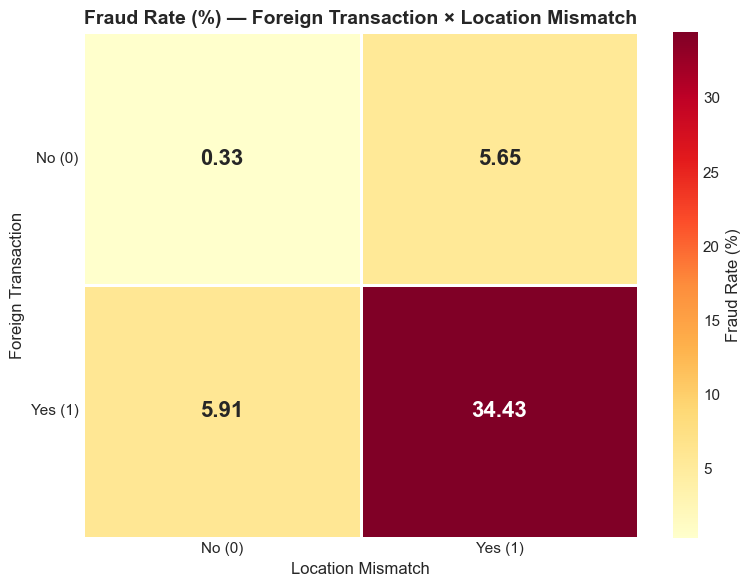


🔍 Key Insight: When BOTH foreign_transaction=1 AND location_mismatch=1,
   the fraud rate is dramatically higher than the baseline.
   This interaction is a very strong fraud signal.


In [20]:
# Cross-tabulation
ct = pd.crosstab([train_df['foreign_transaction'], train_df['location_mismatch']],
                 train_df['is_fraud'], margins=True)
ct_pct = pd.crosstab([train_df['foreign_transaction'], train_df['location_mismatch']],
                      train_df['is_fraud'], normalize='index') * 100

print('Cross-tabulation: Foreign Transaction × Location Mismatch × Fraud')
print('='*65)
print(ct)
print()
print('Fraud Rate (%):')
print(ct_pct.round(2))

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
interaction = train_df.groupby(['foreign_transaction', 'location_mismatch'])['is_fraud'].mean() * 100
interaction = interaction.unstack()
sns.heatmap(interaction, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, cbar_kws={'label': 'Fraud Rate (%)'},
            linewidths=2, linecolor='white',
            annot_kws={'size': 16, 'fontweight': 'bold'})
ax.set_title('Fraud Rate (%) — Foreign Transaction × Location Mismatch',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Location Mismatch', fontsize=12)
ax.set_ylabel('Foreign Transaction', fontsize=12)
ax.set_xticklabels(['No (0)', 'Yes (1)'])
ax.set_yticklabels(['No (0)', 'Yes (1)'], rotation=0)
plt.tight_layout()
plt.show()

print()
print('🔍 Key Insight: When BOTH foreign_transaction=1 AND location_mismatch=1,')
print('   the fraud rate is dramatically higher than the baseline.')
print('   This interaction is a very strong fraud signal.')

### 9.2 Pairplot — Key Features Colored by Fraud

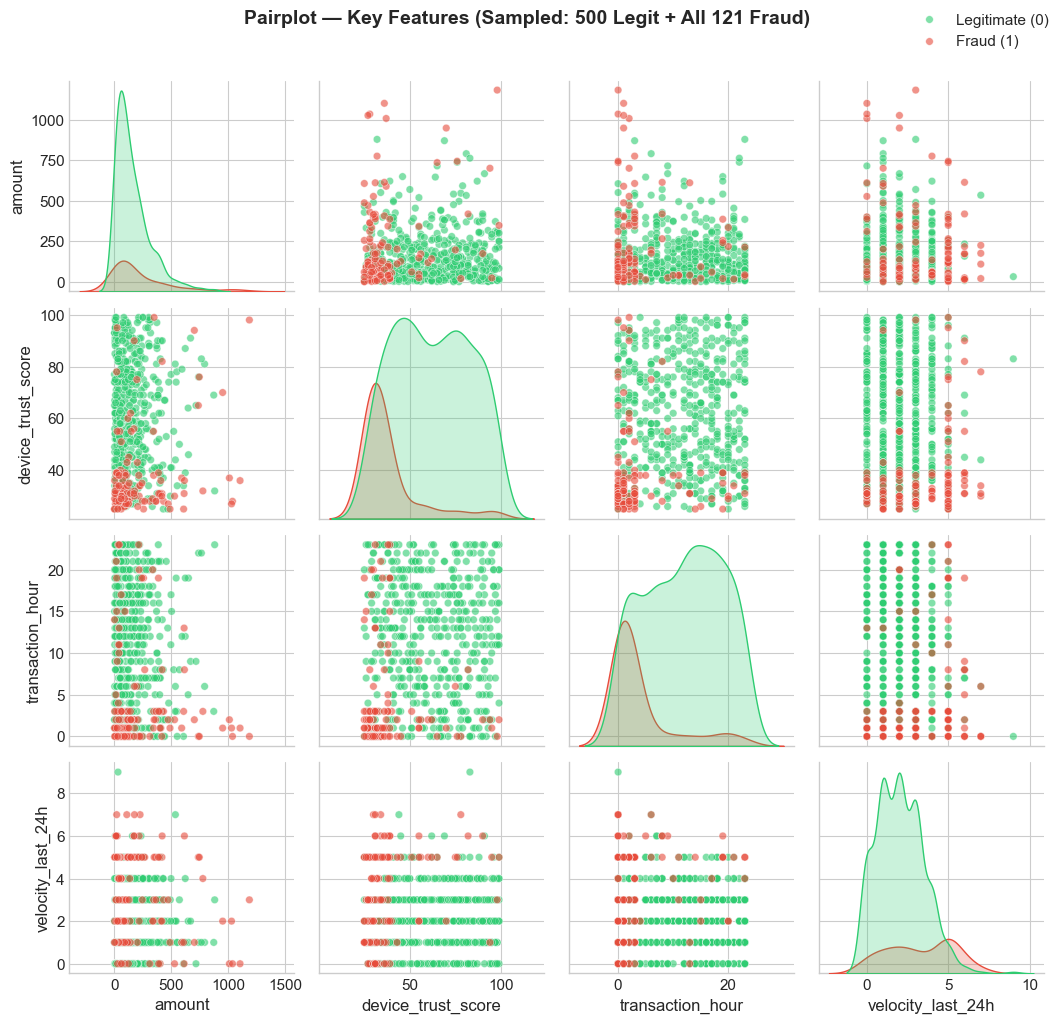

In [21]:
# Select key features for pairplot
pair_features = ['amount', 'device_trust_score', 'transaction_hour',
                 'velocity_last_24h', 'is_fraud']

# Sample for performance (use all fraud + sample of legit)
fraud_samples = train_df[train_df['is_fraud'] == 1][pair_features]
legit_samples = train_df[train_df['is_fraud'] == 0][pair_features].sample(500, random_state=42)
pair_data = pd.concat([legit_samples, fraud_samples])

g = sns.pairplot(pair_data, hue='is_fraud', palette=FRAUD_PALETTE,
                 diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30},
                 height=2.5, aspect=1)
g.fig.suptitle('Pairplot — Key Features (Sampled: 500 Legit + All 121 Fraud)',
               fontweight='bold', fontsize=14, y=1.02)

# Update legend
handles = g._legend_data.values()
labels = ['Legitimate (0)', 'Fraud (1)']
g._legend.remove()
g.fig.legend(handles, labels, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

## 10. Outlier Analysis

Examining outliers using the IQR (Interquartile Range) method.

In [22]:
def count_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), lower, upper

print(f'{"Feature":<22} {"Outliers":>10} {"% of Data":>10} {"Lower Bound":>14} {"Upper Bound":>14}')
print('=' * 72)

outlier_data = []
for col in numeric_features:
    n_out, lower, upper = count_outliers(train_df, col)
    pct = n_out / len(train_df) * 100
    outlier_data.append({'Feature': col, 'Outliers': n_out, 'Pct': pct})
    print(f'{col:<22} {n_out:>10} {pct:>9.2f}% {lower:>14.2f} {upper:>14.2f}')

print()
print('⚠️  Outliers in amount (5%) and velocity_last_24h (0.5%) exist but should NOT be removed.')
print('    In fraud detection, outliers are SIGNAL, not noise — anomalous patterns indicate fraud.')

Feature                  Outliers  % of Data    Lower Bound    Upper Bound
amount                        401      5.01%        -238.46         530.11
transaction_hour                0      0.00%         -12.00          36.00
device_trust_score              0      0.00%         -10.00         134.00
velocity_last_24h              41      0.51%          -2.00           6.00
cardholder_age                  0      0.00%          -9.00          95.00

⚠️  Outliers in amount (5%) and velocity_last_24h (0.5%) exist but should NOT be removed.
    In fraud detection, outliers are SIGNAL, not noise — anomalous patterns indicate fraud.


## 11. Train vs Test Distribution Comparison

Ensuring no significant distribution drift between training and test sets.

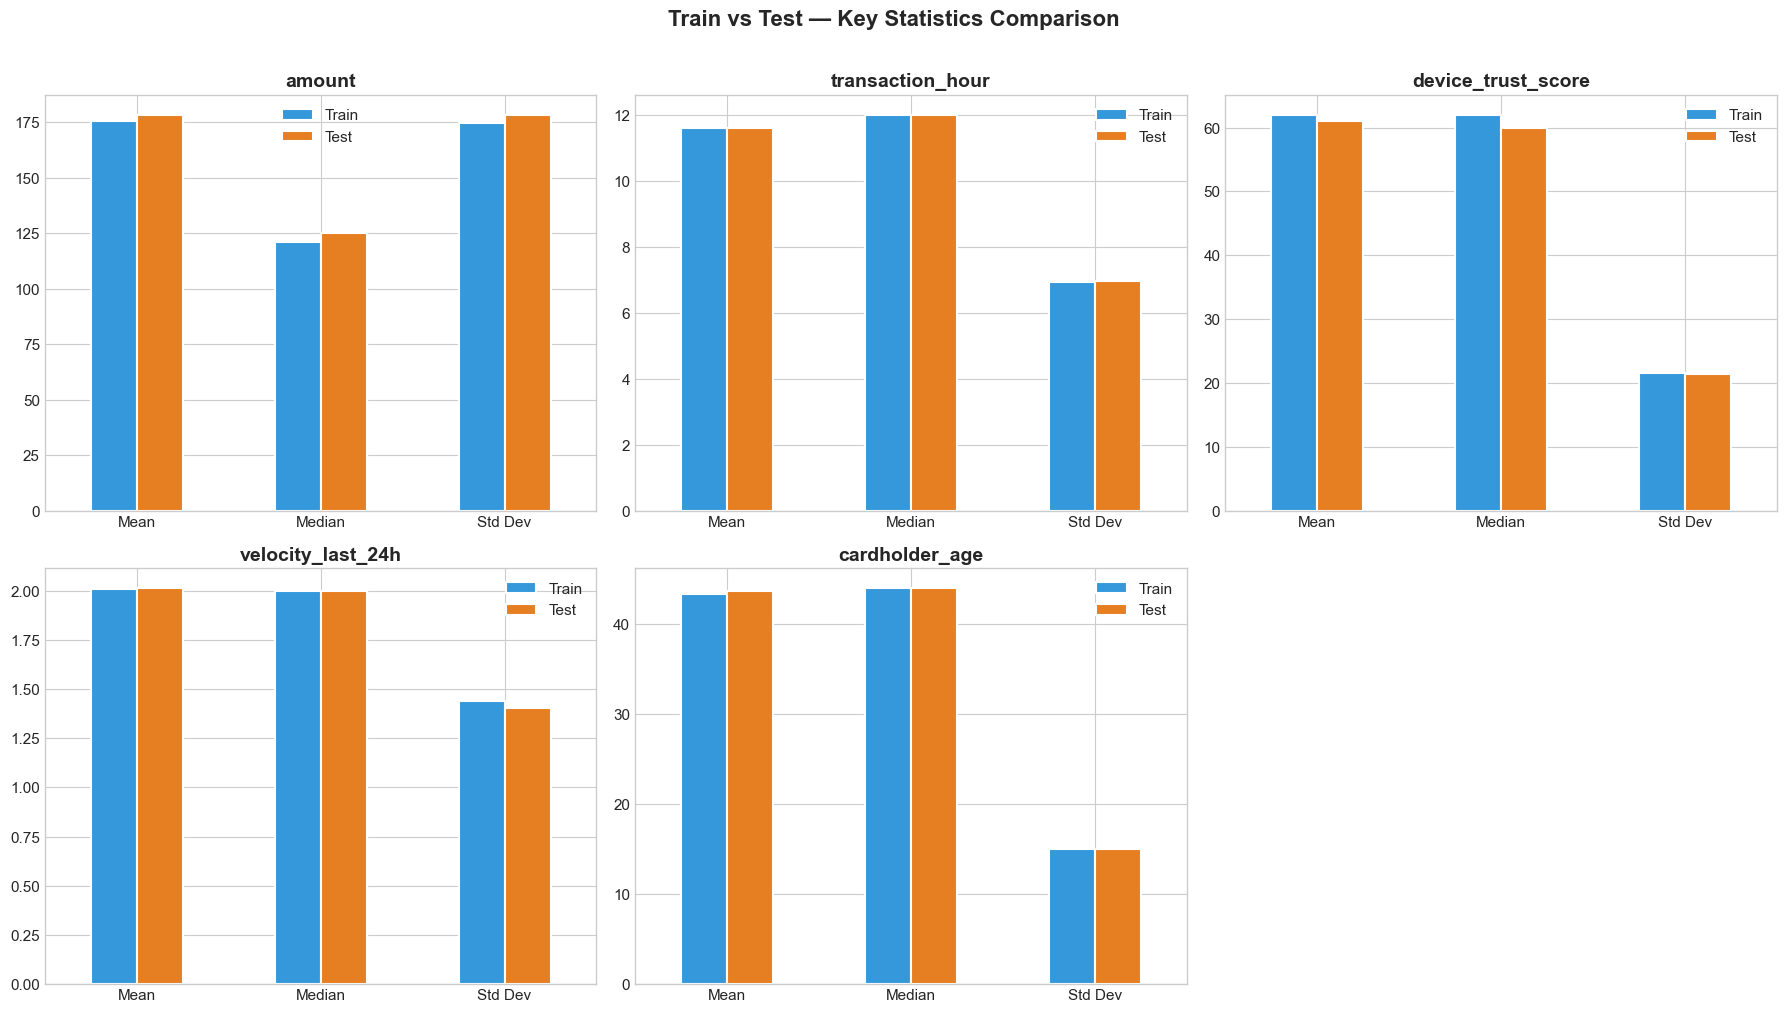

✅ All features show very similar distributions between train and test sets.
   No distribution drift correction is needed.


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    train_stats = train_df[col].describe()
    test_stats = test_df[col].describe()
    
    stats_df = pd.DataFrame({'Train': train_stats, 'Test': test_stats})
    stats_df.loc[['mean', '50%', 'std']].plot(kind='bar', ax=axes[i], color=['#3498db', '#e67e22'],
                                               edgecolor='white', linewidth=1.5)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xticklabels(['Mean', 'Median', 'Std Dev'], rotation=0)
    axes[i].legend()

axes[5].set_visible(False)

plt.suptitle('Train vs Test — Key Statistics Comparison', fontweight='bold', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

print('✅ All features show very similar distributions between train and test sets.')
print('   No distribution drift correction is needed.')

## 12. Zero & Edge Value Analysis

In [24]:
zero_counts = {}
for col in numeric_features:
    zeros = (train_df[col] == 0).sum()
    zero_counts[col] = zeros

print(f'{"Feature":<22} {"Zero Count":>12} {"Interpretation"}')
print('=' * 75)
print(f'{"amount":<22} {zero_counts["amount"]:>12}   $0.00 transaction — possible test/probe charge (fraud pattern)')
print(f'{"transaction_hour":<22} {zero_counts["transaction_hour"]:>12}   Valid — hour 0 = midnight')
print(f'{"device_trust_score":<22} {zero_counts["device_trust_score"]:>12}   No zeros (min is 25)')
print(f'{"velocity_last_24h":<22} {zero_counts["velocity_last_24h"]:>12}   Valid — 0 means no prior transactions in 24h')
print(f'{"cardholder_age":<22} {zero_counts["cardholder_age"]:>12}   No zeros (min is 18)')
print()
print('✅ No negative values found in any feature.')
print('✅ Zero values are valid and meaningful in context — no cleaning needed.')

Feature                  Zero Count Interpretation
amount                            1   $0.00 transaction — possible test/probe charge (fraud pattern)
transaction_hour                341   Valid — hour 0 = midnight
device_trust_score                0   No zeros (min is 25)
velocity_last_24h              1120   Valid — 0 means no prior transactions in 24h
cardholder_age                    0   No zeros (min is 18)

✅ No negative values found in any feature.
✅ Zero values are valid and meaningful in context — no cleaning needed.


## 13. EDA Summary & Key Takeaways

### Data Quality
| Check | Result |
|---|---|
| Missing values | ✅ None |
| Duplicates | ✅ None |
| Data type issues | ✅ None |
| Train/Test drift | ✅ Distributions aligned |
| Negative values | ✅ None |

### Critical Finding: Severe Class Imbalance
- **98.49% Legitimate vs 1.51% Fraud** (65:1 ratio)
- Must be addressed during modeling with SMOTE, class weights, or ensemble methods

### Fraud Signal Strength (Ranked)

| Rank | Feature | Signal Strength | Details |
|---|---|---|---|
| 1 | `location_mismatch` | 🔴 **Strong** (5.5×) | 8.24% fraud rate when 1, vs 1.51% baseline |
| 2 | `foreign_transaction` | 🔴 **Strong** (5.4×) | 8.12% fraud rate when 1, vs 1.51% baseline |
| 3 | `device_trust_score` | 🔴 **Strong** (4×) | 6.04% fraud rate when score 20-40 |
| 4 | `transaction_hour` | 🟠 **Moderate** (3.3×) | 4.91% fraud rate during night hours (0-5) |
| 5 | `velocity_last_24h` | 🟡 **Mild** | Positive correlation (+0.110) |
| 6 | `amount` | 🟡 **Mild** | 3.04% fraud rate for $500+ (2× baseline) |
| 7 | `cardholder_age` | ⚪ **None** | Zero correlation with fraud |

### Feature Interactions
- **`foreign_transaction` × `location_mismatch`** is the strongest combined signal
- This interaction should be engineered as a feature during preprocessing

### Recommendations for Next Steps
1. **Drop** `transaction_id` (no predictive value)
2. **Encode** `merchant_category` (one-hot encoding — only 5 categories)
3. **Engineer** interaction features (`foreign_transaction × location_mismatch`, `is_night`)
4. **Address imbalance** using SMOTE or class weights during modeling
5. **Consider dropping** `cardholder_age` (zero signal) or keep for completeness
6. **Use tree-based models** (XGBoost, LightGBM) — they handle this type of data well

---
*Notebook completed. Proceed to `02_Data_Preprocessing.ipynb` for data cleaning and feature engineering.*